# Unsupervised HP search + multi-seed finals

Teaching companion to the LV protocol in the README.

Hyperparameters are selected by **held-out unsupervised metrics** only (Bernoulli LL or AUC for LV; negated mean Jaccard cost for NTAC; negated row MSE for PCA). Ground-truth Hungarian / ARI / NMI are reported on multi-seed final runs and are never used for selection.

Expected artefacts from `run_experiments.py` / `launch_lightning_sweep.py`:
- `hp_results.csv`, `hp_best.json`
- `final_results.csv`, `final_summary.csv`

The notebook adapts to whichever of `pca`, `lv`, `ntac` are present. Legacy `lv_e` / `gnn` rows in older CSVs are harmless if they appear, but those trainers are no longer in the tree: the positive lesson is the LV data pipeline and optimization protocol, not extra capacity.

Because selection metrics differ in meaning and scale across methods, `val_metric` is only ever plotted on **per-method axes**. Only the ground-truth metrics are comparable across methods. The Spearman correlation $\rho(\texttt{val\_metric}, \texttt{gt\_hungarian})$ is the headline diagnostic: it should be strongly positive for a useful unsupervised selector (it is for LV under the current protocol).

Reference lines on the finals plot: random $K$-assignment baseline and theoretical Hungarian max ($n_{\mathrm{shared}}$).

Finals plots also show $K_{\mathrm{pred}}$ (occupied clusters on the labelled set).
Hungarian alone is not resolution-matched when that differs across methods.


In [35]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["figure.dpi"] = 120
PALETTE = {
    "pca": "#6c757d",
    "lv": "#e76f51",
    "ntac": "#bc6c25",
}
METHOD_ORDER = ["pca", "lv", "ntac"]

# Past |eta| ~ 17 the float32 sigmoid is exactly 0 or 1, every gradient is exactly
# zero and the decoder freezes: the collapse this repository fixed.
FLOAT32_SATURATION = 17.0


def methods_present(df: pd.DataFrame) -> list[str]:
    found = set(df["method"].unique())
    return [m for m in METHOD_ORDER if m in found] + sorted(found - set(METHOD_ORDER))


def group_col(df: pd.DataFrame) -> str:
    """Finals are summarised per ``group`` when a sweep retrained several variants."""
    return "group" if "group" in df.columns and df["group"].notna().any() else "method"


def groups_present(df: pd.DataFrame) -> list[str]:
    col = group_col(df)
    if col == "method":
        return methods_present(df)
    order = {m: i for i, m in enumerate(METHOD_ORDER)}
    pairs = df[["method", col]].dropna().drop_duplicates().itertuples(index=False)
    return [g for _, g in sorted(pairs, key=lambda p: (order.get(p[0], 99), str(p[1])))]


def group_palette(df: pd.DataFrame, groups: list[str]) -> dict[str, str]:
    col = group_col(df)
    method_of = {
        g: m for m, g in df[["method", col]].dropna().drop_duplicates().itertuples(index=False)
    }
    return {g: PALETTE.get(method_of.get(g, g), "#333333") for g in groups}


def constraint_arm(row: pd.Series) -> str:
    """Compact label for the block-logit constraint of one run.

    ``none`` is the historical unconstrained decoder; the ``unit`` arms are named
    by how the scale $s$ is carried and by its initialisation, because the
    guarantee differs between them (`fixed` exact, `learned` conditional,
    `per_row` none).
    """
    u_norm = row.get("u_norm")
    if not isinstance(u_norm, str):
        return "n/a"
    if u_norm != "unit":
        return "none"
    init = row.get("u_scale_init")
    init_txt = f"@{init:g}" if pd.notna(init) else ""
    return f"unit/{row.get('u_scale', '?')}{init_txt}"

## 1. Hyperparameter search (unsupervised selection)

In [36]:
hp = pd.read_csv("hp_results.csv")
best = json.loads(Path("hp_best.json").read_text())


def attach_val_auc(df: pd.DataFrame) -> pd.DataFrame:
    """Join the calibration-invariant held-out AUC from the per-run metrics JSON.

    ``val_auc`` is written by the LV trainers but is not part of the
    aggregated CSVs; PCA and NTAC leave it undefined.
    """
    auc = {
        p.name[: -len("_metrics.json")]: json.loads(p.read_text()).get("val_auc")
        for p in Path(".").glob("*_metrics.json")
    }
    joined = df["name"].map(auc)
    # Newer sweeps carry val_auc in the aggregated table already; keep it where the
    # per-run JSON is no longer on disk rather than overwriting it with NaN.
    df["val_auc"] = joined.combine_first(df["val_auc"]) if "val_auc" in df.columns else joined
    return df


hp = attach_val_auc(hp)
HP_COLS = [
    c
    for c in [
        "name", "method", "d", "lr", "likelihood", "bfs_frac", "target_updates",
        "d_e", "e_wd", "layers", "u_norm", "u_scale", "u_scale_init", "label_smoothing",
        "val_metric", "val_auc", "n_pred_clusters", "gt_n_pred_clusters", "gt_n_gt_clusters",
        "gt_hungarian", "gt_ari", "gt_nmi",
    ]
    if c in hp.columns
]
# Diagnostics of the decoder itself, reported per run but not part of the grid.
DIAG_COLS = [
    c
    for c in [
        "max_abs_train_logit", "decoder_bias", "u_scale_value", "u_scale_value_max",
        "best_epoch", "last_epoch", "last_gt_hungarian", "skipped_updates",
    ]
    if c in hp.columns
]
display(
    hp.sort_values(["method", "val_metric"], ascending=[True, False])
    .groupby("method")
    .head(5)[HP_COLS]
)
print("Selected by val_metric:")
display(pd.DataFrame([
    {"method": m, "name": v["name"], "val_metric": v["val_metric"], **v["hyperparams"]}
    for m, v in best.items()
]))

,name,method,d,lr,likelihood,bfs_frac,target_updates,d_e,e_wd,layers,u_norm,u_scale,u_scale_init,label_smoothing,val_metric,val_auc,gt_hungarian,gt_ari,gt_nmi
49,hp_gnn_L2_d64_lr0.01_bfs1.0_bernoulli_unit_fix...,gnn,64,0.01,bernoulli,1.0,NaN,NaN,NaN,2.0,unit,fixed,12.0,0.0,-1.154408,0.989293,2712.0,0.014407,0.270598
50,hp_gnn_L0_d64_lr0.03_bfs1.0_bernoulli_unit_fix...,gnn,64,0.03,bernoulli,1.0,NaN,NaN,NaN,0.0,unit,fixed,12.0,0.0,-1.202311,0.991117,13842.0,0.223839,0.610926
51,hp_gnn_L1_d64_lr0.03_bfs1.0_bernoulli_unit_fix...,gnn,64,0.03,bernoulli,1.0,NaN,NaN,NaN,1.0,unit,fixed,12.0,0.0,-1.244560,0.990103,6444.0,0.065926,0.406933
52,hp_gnn_L1_d64_lr0.1_bfs1.0_bernoulli_unit_fixe...,gnn,64,0.10,bernoulli,1.0,NaN,NaN,NaN,1.0,unit,fixed,12.0,0.0,-1.258851,0.981686,7646.0,0.087349,0.446751
53,hp_gnn_L1_d64_lr0.01_bfs1.0_bernoulli_unit_fix...,gnn,64,0.01,bernoulli,1.0,NaN,NaN,NaN,1.0,unit,fixed,12.0,0.0,-1.262641,0.988995,3355.0,0.022521,0.309142
23,hp_lv_d256_lr0.03_bfs1.0_bernoulli_unit_fixed12.0,lv,256,0.03,bernoulli,1.0,NaN,NaN,NaN,NaN,unit,fixed,12.0,0.0,-1.665582,0.978600,23208.0,0.440381,0.821575
2,hp_lv_d64_lr0.03_bfs1.0_bernoulli_unit_fixed12.0,lv,64,0.03,bernoulli,1.0,NaN,NaN,NaN,NaN,unit,fixed,12.0,0.0,-1.684145,0.977729,24886.0,0.505134,0.828523
3,hp_lv_d64_lr0.03_bfs1.0_bernoulli_unit_learned8.0,lv,64,0.03,bernoulli,1.0,NaN,NaN,NaN,NaN,unit,learned,8.0,0.0,-1.697204,0.976392,21996.0,0.420958,0.799552
6,hp_lv_d64_lr0.03_bfs1.0_bernoulli_unit_per_row...,lv,64,0.03,bernoulli,1.0,NaN,NaN,NaN,NaN,unit,per_row,12.0,0.0,-1.711514,0.975991,23005.0,0.441847,0.816438
4,hp_lv_d64_lr0.03_bfs1.0_bernoulli_unit_learned...,lv,64,0.03,bernoulli,1.0,NaN,NaN,NaN,NaN,unit,learned,12.0,0.0,-1.712270,0.975873,21912.0,0.436648,0.791154


Selected by val_metric:


,method,name,val_metric,d,lr,layers,propagation,gnn_norm,bfs_frac,likelihood,label_smoothing,u_norm,u_scale,u_scale_init,d_e,e_wd,max_k,max_iterations,frac_seeds
0,gnn,hp_gnn_L2_d64_lr0.01_bfs1.0_bernoulli_unit_fix...,-1.154408,64,0.01,2.0,subgraph,unit,1.0,bernoulli,0.0,unit,fixed,12.0,NaN,NaN,NaN,NaN,NaN
1,lv,hp_lv_d256_lr0.03_bfs1.0_bernoulli_unit_fixed12.0,-1.665582,256,0.03,NaN,NaN,NaN,1.0,bernoulli,0.0,unit,fixed,12.0,NaN,NaN,NaN,NaN,NaN
2,lv_e,hp_lv_e_d64_de16_lr0.05_ewd0.01_bfs1.0_poisson,-1.397446,64,0.05,NaN,NaN,NaN,1.0,poisson,NaN,NaN,NaN,NaN,16.0,0.01,NaN,NaN,NaN
3,ntac,hp_ntac_k729_R12_T0.1,-0.480313,729,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,729.0,12.0,0.1
4,pca,hp_pca_d32_lr0.01,-53.905715,32,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


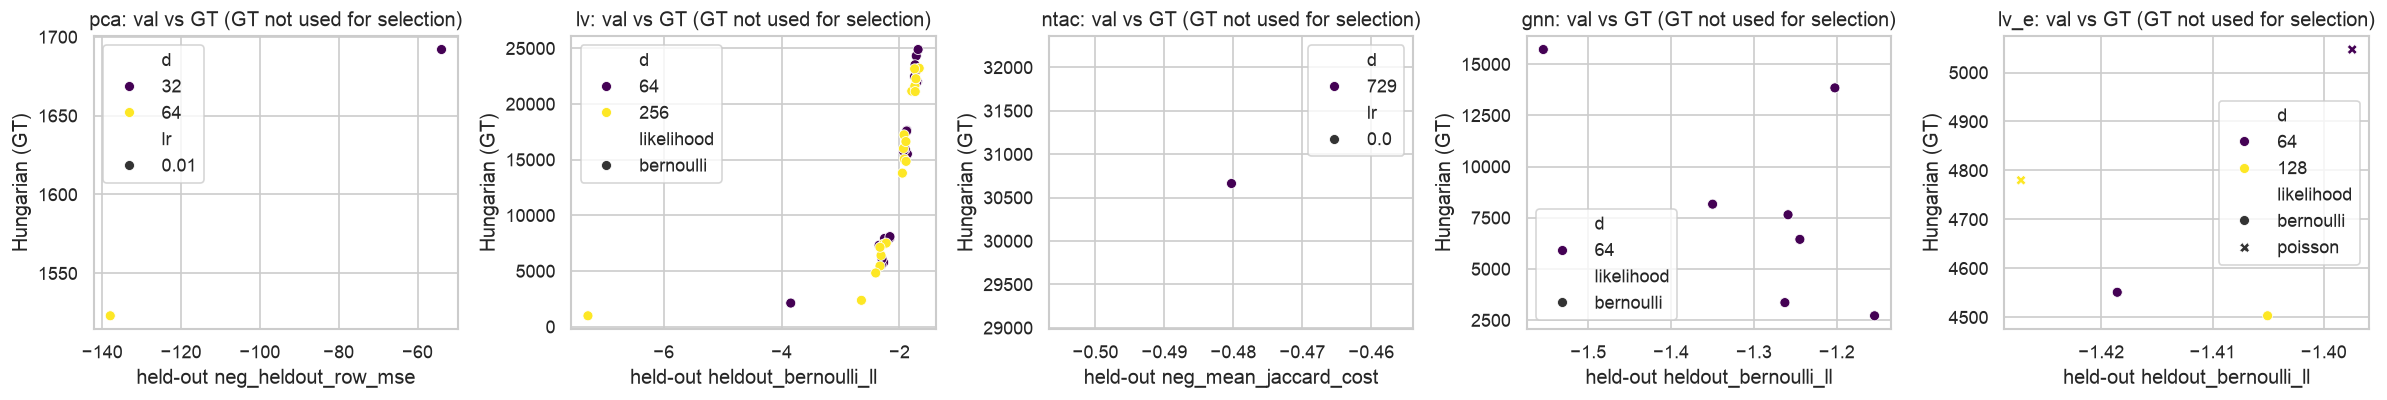

Selection metric per method (not comparable across methods):
  pca: neg_heldout_row_mse in [-137.9724, -53.9057] over 2 configuration(s)
  lv: heldout_bernoulli_ll in [-7.2869, -1.6656] over 42 configuration(s)
  ntac: neg_mean_jaccard_cost in [-0.4803, -0.4803] over 1 configuration(s)
  gnn: heldout_bernoulli_ll in [-1.5543, -1.1544] over 7 configuration(s)
  lv_e: heldout_bernoulli_ll in [-1.4272, -1.3974] over 4 configuration(s)
Spearman rho(val_metric, gt_hungarian) — selection/ground-truth agreement:
  pca: too few configurations (2) for a rank correlation
  lv: rho=+0.954 over 42 config(s); argmax DISAGREE
      val-best: hp_lv_d256_lr0.03_bfs1.0_bernoulli_unit_fixed12.0
      GT-best : hp_lv_d64_lr0.03_bfs1.0_bernoulli_unit_fixed12.0
  ntac: too few configurations (1) for a rank correlation
  gnn: rho=-0.536 over 7 config(s); argmax DISAGREE
      val-best: hp_gnn_L2_d64_lr0.01_bfs1.0_bernoulli_unit_fixed12.0_gnnunit
      GT-best : hp_gnn_L0_d64_lr0.1_bfs1.0_bernoulli_unit_fixe

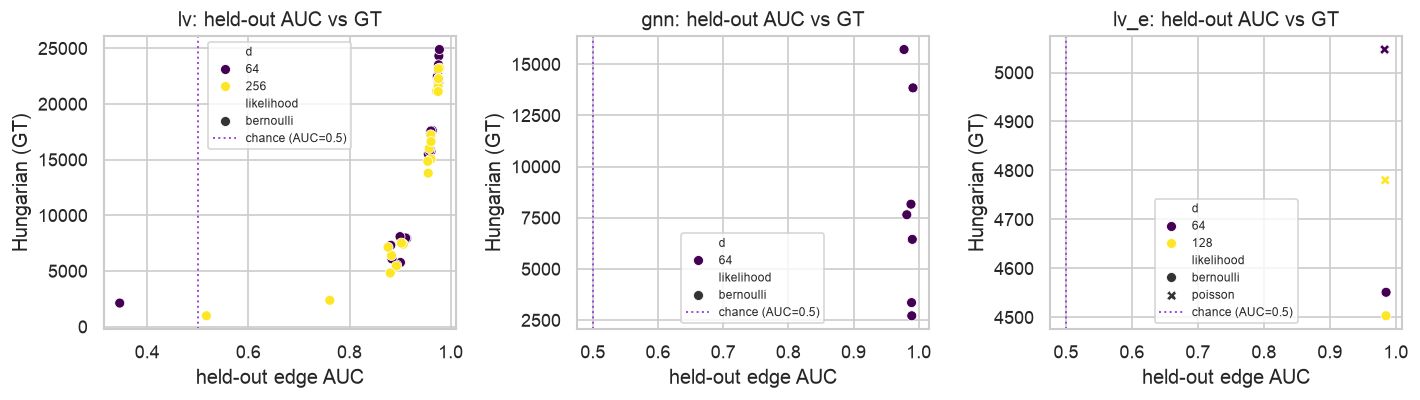

In [37]:
# `val_metric` is method-specific (Bernoulli LL, negated row MSE, negated mean
# Jaccard cost), so every method gets its own x-axis: values are NOT comparable
# across panels and must never be pooled on a shared axis.
methods = methods_present(hp)
metric_names = hp.groupby("method")["val_metric_name"].first().to_dict()
n = max(len(methods), 1)
fig, axes = plt.subplots(1, n, figsize=(4.0 * n, 3.5), sharex=False, sharey=False)
if n == 1:
    axes = [axes]
for ax, method in zip(axes, methods):
    sub = hp[hp["method"] == method].copy()
    # Likelihood is the more informative second channel wherever it is defined
    # (LV); PCA and NTAC fall back to the learning rate.
    style_col = "likelihood" if sub.get("likelihood", pd.Series(dtype=object)).notna().any() else "lr"
    sns.scatterplot(
        data=sub, x="val_metric", y="gt_hungarian",
        hue="d", style=style_col, ax=ax, palette="viridis",
    )
    ax.set_title(f"{method}: val vs GT (GT not used for selection)")
    ax.set_xlabel(f"held-out {metric_names.get(method, 'val_metric')}")
    ax.set_ylabel("Hungarian (GT)")
plt.tight_layout()
plt.show()

print("Selection metric per method (not comparable across methods):")
for method in methods:
    sub = hp[hp["method"] == method]
    print(
        f"  {method}: {metric_names.get(method, 'val_metric')} "
        f"in [{sub['val_metric'].min():.4f}, {sub['val_metric'].max():.4f}] "
        f"over {len(sub)} configuration(s)"
    )

# Does the unsupervised selection metric rank configurations the way ground truth
# does? A low or negative rho means val_metric and Hungarian disagree, so the
# selected configuration need not be the ground-truth optimum.
print("Spearman rho(val_metric, gt_hungarian) — selection/ground-truth agreement:")
for method in methods:
    sub = hp[hp["method"] == method]
    if len(sub) > 2:
        rho = sub["val_metric"].corr(sub["gt_hungarian"], method="spearman")
        argmax_val = sub.loc[sub["val_metric"].idxmax(), "name"]
        argmax_gt = sub.loc[sub["gt_hungarian"].idxmax(), "name"]
        agree = "agree" if argmax_val == argmax_gt else "DISAGREE"
        print(f"  {method}: rho={rho:+.3f} over {len(sub)} config(s); argmax {agree}")
        if argmax_val != argmax_gt:
            print(f"      val-best: {argmax_val}\n      GT-best : {argmax_gt}")
    else:
        print(f"  {method}: too few configurations ({len(sub)}) for a rank correlation")

# Held-out AUC is calibration-invariant (only defined for LV).
if hp["val_auc"].notna().any():
    auc_methods = [m for m in methods if hp.loc[hp["method"] == m, "val_auc"].notna().any()]
    fig, axes = plt.subplots(1, len(auc_methods), figsize=(4.0 * len(auc_methods), 3.5))
    axes = np.atleast_1d(axes)
    for ax, method in zip(axes, auc_methods):
        sub = hp[(hp["method"] == method) & hp["val_auc"].notna()]
        style_col = "likelihood" if sub["likelihood"].notna().any() else "lr"
        sns.scatterplot(
            data=sub, x="val_auc", y="gt_hungarian",
            hue="d", style=style_col, ax=ax, palette="viridis",
        )
        ax.axvline(0.5, color="#9d4edd", ls=":", lw=1.2, label="chance (AUC=0.5)")
        ax.set_title(f"{method}: held-out AUC vs GT")
        ax.set_xlabel("held-out edge AUC")
        ax.set_ylabel("Hungarian (GT)")
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

# Matched-compute bfs_frac=0 controls, when the sweep included them.
if "bfs_frac" in hp.columns and (hp["bfs_frac"] == 0.0).any():
    print("Matched-compute bfs_frac=0 control(s):")
    display(hp[hp["bfs_frac"] == 0.0][HP_COLS])


## 2. The block-logit constraint

The Bernoulli decoder $\eta_{kk'} = u_k^\top v_{k'} + b$ is bilinear in unconstrained embeddings, and past $\lvert\eta\rvert\approx17$ the float32 $\sigma(\eta)$ is exactly $0$ or $1$: every gradient is exactly zero and the parameters freeze. `--u-norm unit` replaces the inner product by a scaled cosine similarity, $\eta_{kk'} = s\,\hat u_k^\top\hat v_{k'} + b$ with $\lvert\eta - b\rvert \le s$, and `--u-scale {fixed,learned,per_row}` chooses how $s$ is carried — an exact guarantee, one conditional on a scale that in fact stays bounded, and none at all.

This section reads the axes that constraint added (`u_norm`, `u_scale`, `u_scale_init`, `label_smoothing`) and the decoder diagnostics they act on. Every panel is skipped with a printed note when the columns it needs are absent, so a sweep that predates these flags still runs the notebook end to end.

Four things are worth looking at here, in order: whether accuracy is still moving with the learning rate at the edge of the swept grid; whether the realised $\max\lvert\eta\rvert$ respects the bound each arm claims; whether the learned scale agrees with the fixed one that was selected; and how much ground-truth agreement the best-validation checkpoint gives up against the last epoch.

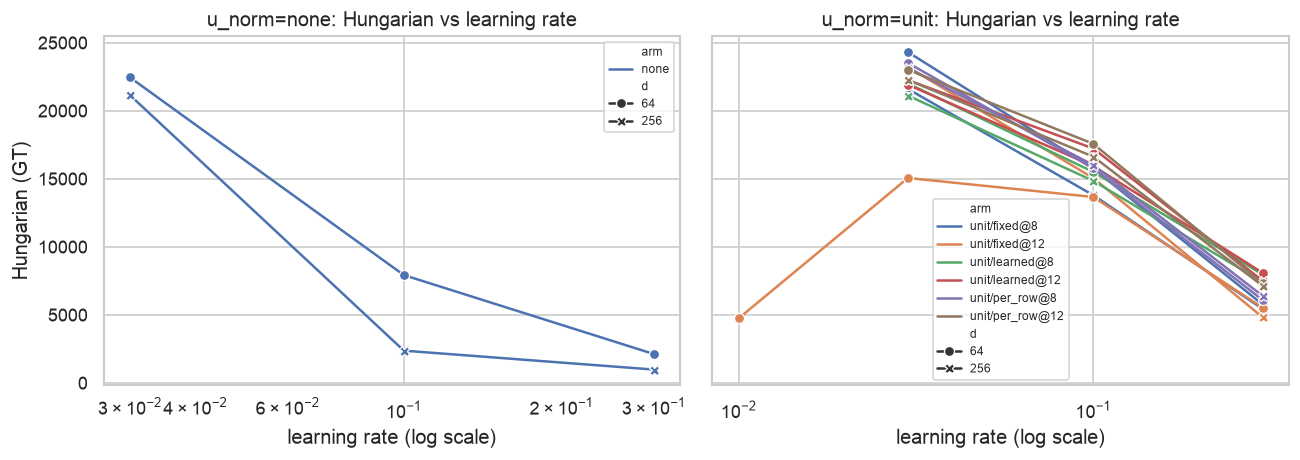

Hungarian by arm x learning rate (mean over widths):


lr,0.01,0.03,0.10,0.30
arm,,,,
none,<NA>,21801,5145,1550
unit/fixed@12,4743,17095,14008,5178
unit/fixed@8,<NA>,22956,14766,5603
unit/learned@12,<NA>,22082,16578,7795
unit/learned@8,<NA>,21554,15174,7686
unit/per_row@12,<NA>,22634,17094,7220
unit/per_row@8,<NA>,23334,15888,6242


monotone decreasing in lr: 6/7 arm(s) over lr in [0.01, 0.03, 0.1, 0.3]
  the smallest swept lr is 0.01 and it is the best one; the optimum is therefore probably below the grid


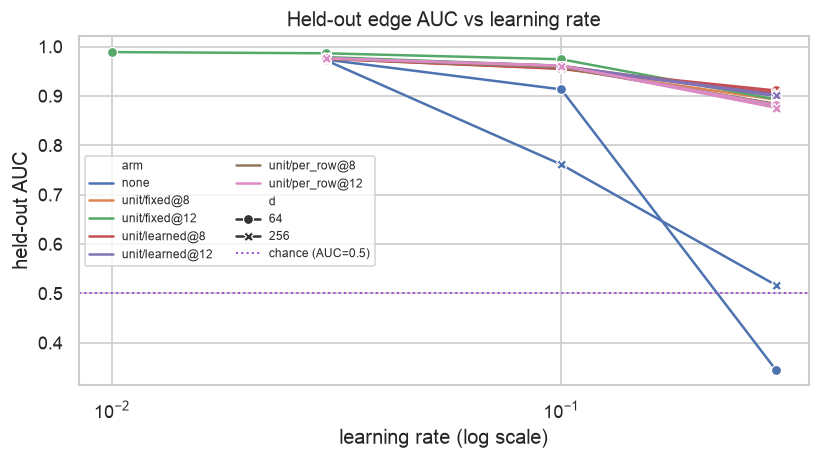

In [38]:
# Ground truth against learning rate, split by whether the block logit is bounded.
# This is the clearest single picture of the constraint result: the constrained arms
# dominate at every learning rate, and every arm is monotone decreasing in lr, so
# the selected lr sitting at the bottom edge of the grid means the optimum is
# probably outside it.
CONSTRAINT_COLS = {"u_norm", "u_scale", "u_scale_init"}
con = hp[hp["u_norm"].notna()].copy() if "u_norm" in hp.columns else hp.iloc[:0].copy()

if con.empty or not CONSTRAINT_COLS.issubset(hp.columns):
    print(
        "no u_norm / u_scale columns in hp_results.csv: this sweep predates the "
        "block-logit constraint, so the constraint panels are skipped"
    )
else:
    con["arm"] = con.apply(constraint_arm, axis=1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), sharey=True)
    for ax, (norm, sub) in zip(axes, con.groupby("u_norm")):
        sns.lineplot(
            data=sub, x="lr", y="gt_hungarian", hue="arm", style="d",
            markers=True, dashes=False, ax=ax, errorbar=None,
        )
        ax.set_xscale("log")
        ax.set_title(f"u_norm={norm}: Hungarian vs learning rate")
        ax.set_xlabel("learning rate (log scale)")
        ax.set_ylabel("Hungarian (GT)")
        ax.legend(fontsize=7, title=None)
    plt.tight_layout()
    plt.show()

    # The same numbers as a table, averaged over the widths, because the ordering of
    # the arms is easier to read than to see.
    print("Hungarian by arm x learning rate (mean over widths):")
    display(
        con.pivot_table(index="arm", columns="lr", values="gt_hungarian", aggfunc="mean")
        .round(0)
        .astype("Int64")
    )
    monotone = [
        arm
        for arm, sub in con.groupby("arm")
        if sub.groupby("lr")["gt_hungarian"].mean().is_monotonic_decreasing
    ]
    lrs = sorted(float(v) for v in con["lr"].unique())
    print(
        f"monotone decreasing in lr: {len(monotone)}/{con['arm'].nunique()} arm(s) "
        f"over lr in [{', '.join(f'{v:g}' for v in lrs)}]"
    )
    if monotone and lrs:
        print(
            f"  the smallest swept lr is {min(lrs):g} and it is the best one; the optimum "
            "is therefore probably below the grid"
        )

    # Held-out AUC on the same axis: 0.5 is chance, and a collapsed decoder sits there
    # exactly rather than approximately.
    fig, ax = plt.subplots(figsize=(7, 4.0))
    sns.lineplot(
        data=con, x="lr", y="val_auc", hue="arm", style="d",
        markers=True, dashes=False, ax=ax, errorbar=None,
    )
    ax.set_xscale("log")
    ax.axhline(0.5, color="#9d4edd", ls=":", lw=1.2, label="chance (AUC=0.5)")
    ax.set_title("Held-out edge AUC vs learning rate")
    ax.set_xlabel("learning rate (log scale)")
    ax.set_ylabel("held-out AUC")
    ax.legend(fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()

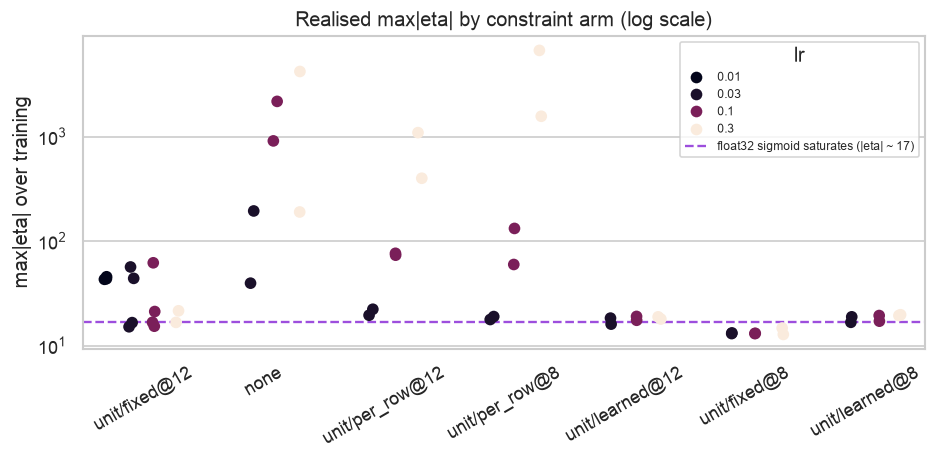

36/49 run(s) exceeded |eta| ~ 17, which is expected wherever |b| + s already does; 10 exceeded 100, which no bounded decoder can:


,name,arm,d,lr,max_abs_train_logit,u_scale_value_max,val_auc,gt_hungarian
40,hp_lv_d256_lr0.3_bfs1.0_bernoulli_unit_per_row8.0,unit/per_row@8,256,0.30,6690.129395,31.422991,0.882974,6396.0
14,hp_lv_d64_lr0.3_bfs1.0_bernoulli,none,64,0.30,4204.834473,NaN,0.345647,2120.0
28,hp_lv_d256_lr0.1_bfs1.0_bernoulli,none,256,0.10,2175.456299,NaN,0.761065,2368.0
19,hp_lv_d64_lr0.3_bfs1.0_bernoulli_unit_per_row8.0,unit/per_row@8,64,0.30,1567.147461,31.988102,0.883897,6088.0
20,hp_lv_d64_lr0.3_bfs1.0_bernoulli_unit_per_row12.0,unit/per_row@12,64,0.30,1092.552734,27.750250,0.881684,7309.0
7,hp_lv_d64_lr0.1_bfs1.0_bernoulli,none,64,0.10,910.597290,NaN,0.913208,7922.0
41,hp_lv_d256_lr0.3_bfs1.0_bernoulli_unit_per_row...,unit/per_row@12,256,0.30,399.870514,38.259541,0.876211,7130.0
21,hp_lv_d256_lr0.03_bfs1.0_bernoulli,none,256,0.03,194.453201,NaN,0.971910,21151.0
35,hp_lv_d256_lr0.3_bfs1.0_bernoulli,none,256,0.30,190.120728,NaN,0.517048,979.0
33,hp_lv_d256_lr0.1_bfs1.0_bernoulli_unit_per_row8.0,unit/per_row@8,256,0.10,132.304703,39.205902,0.957493,16002.0


21 run(s) ended with max_k s_k more than 5% above their initialisation, by u_scale: {'per_row': 12, 'learned': 9}
  learned: max_k s_k up to 14.5 and max|eta| up to 19.7
  per_row: max_k s_k up to 44.5 and max|eta| up to 6690.1
parsed 59 trajectory(ies) from ['unsup_sweep.log', 'lv_sweep_results/lv_unsup_sweep.log', 'lv_dsweep_results/unsup_sweep.log']; 42 match a row of hp_results.csv


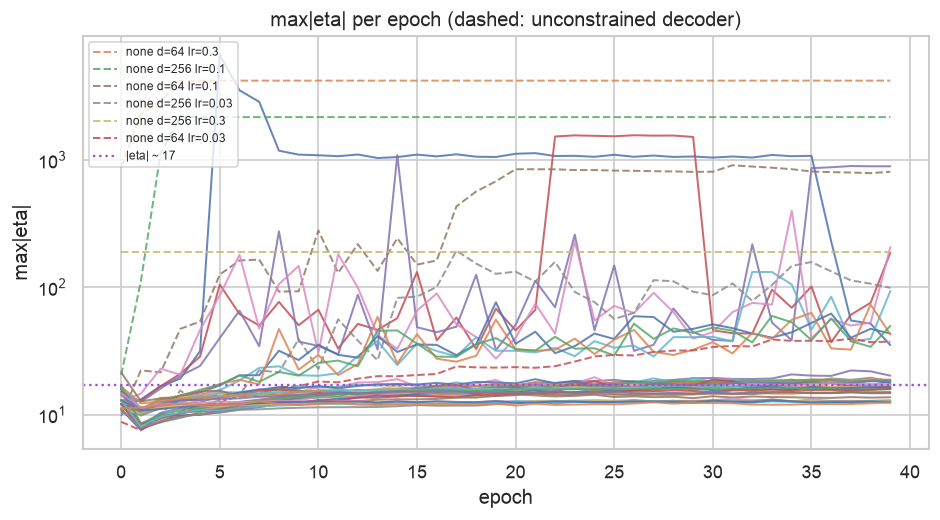

  frozen: hp_lv_d64_lr0.3_bfs1.0_bernoulli holds max|eta|=4204.83 bit-identically over the last 37 epoch(s)
  frozen: hp_lv_d256_lr0.1_bfs1.0_bernoulli holds max|eta|=2175.46 bit-identically over the last 37 epoch(s)
  frozen: hp_lv_d256_lr0.3_bfs1.0_bernoulli holds max|eta|=190.121 bit-identically over the last 40 epoch(s)


In [39]:
# The realised max|eta|, which is where the decoder collapse is visible at all: it
# is invisible in val_metric until saturation has already happened. Log axis, because
# the unconstrained runs span four orders of magnitude.
import re

if con.empty or "max_abs_train_logit" not in hp.columns:
    print("no max_abs_train_logit column: skipping the saturation panels")
else:
    fig, ax = plt.subplots(figsize=(8, 4.0))
    sns.stripplot(
        data=con.sort_values("lr"), x="arm", y="max_abs_train_logit",
        hue="lr", dodge=True, palette="rocket", ax=ax, size=7,
    )
    ax.set_yscale("log")
    ax.axhline(
        FLOAT32_SATURATION, color="#9d4edd", ls="--", lw=1.4,
        label=f"float32 sigmoid saturates (|eta| ~ {FLOAT32_SATURATION:g})",
    )
    ax.set_title("Realised max|eta| by constraint arm (log scale)")
    ax.set_xlabel("")
    ax.set_ylabel("max|eta| over training")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=7, title="lr")
    plt.tight_layout()
    plt.show()

    # Crossing the saturation line is not by itself pathological: the bound is
    # |eta| <= |b| + s, and with b ~ -8.8 and s = 12 a healthy run spends most of its
    # allowance. What distinguishes a runaway is the order of magnitude.
    RUNAWAY = 100.0
    n_above = int((con["max_abs_train_logit"] > FLOAT32_SATURATION).sum())
    runaway = con[con["max_abs_train_logit"] > RUNAWAY]
    print(
        f"{n_above}/{len(con)} run(s) exceeded |eta| ~ {FLOAT32_SATURATION:g}, which is "
        "expected wherever |b| + s already does; "
        f"{len(runaway)} exceeded {RUNAWAY:g}, which no bounded decoder can:"
    )
    display(
        runaway.sort_values("max_abs_train_logit", ascending=False)[
            [c for c in ["name", "arm", "d", "lr", "max_abs_train_logit", "u_scale_value_max",
                         "val_auc", "gt_hungarian"] if c in runaway.columns]
        ]
    )
    # per_row bounds |eta - b| by max_k s_k rather than by the initialisation, so it is
    # the arm where the realised scale and the realised logit come apart: a scalar scale
    # drifting up is a diagnostic, one row of K escaping is a lost guarantee.
    if "u_scale_value_max" in con.columns and con["u_scale_value_max"].notna().any():
        escaped = con[con["u_scale_value_max"] > con["u_scale_init"] * 1.05]
        print(
            f"{len(escaped)} run(s) ended with max_k s_k more than 5% above their "
            "initialisation, by u_scale:",
            escaped["u_scale"].value_counts().to_dict() or "none",
        )
        for scale, sub in escaped.groupby("u_scale"):
            print(
                f"  {scale}: max_k s_k up to {sub['u_scale_value_max'].max():.1f} "
                f"and max|eta| up to {sub['max_abs_train_logit'].max():.1f}"
            )


def parse_epoch_logits(path: Path) -> dict[str, list[float]]:
    """Per-epoch ``max_abs_logit`` trajectories, keyed by run name, from a sweep log.

    The aggregated tables keep only the maximum over training, which cannot
    distinguish a decoder that grew steadily from one that was thrown past the
    saturation point in two epochs. The trajectory can, and the logs are the only
    place it survives.
    """
    runs: dict[str, list[float]] = {}
    current: str | None = None
    prefix = re.compile(r"--out-prefix\s+(\S+)")
    logit = re.compile(r"max_abs_logit=([0-9.eE+-]+)")
    with path.open(errors="replace") as f:
        for line in f:
            if "--out-prefix" in line and (m := prefix.search(line)):
                current = m.group(1)
                runs.setdefault(current, [])
            elif current and "max_abs_logit=" in line and (m := logit.search(line)):
                runs[current].append(float(m.group(1)))
    return {k: v for k, v in runs.items() if v}


LOG_CANDIDATES = [
    Path("unsup_sweep.log"),
    Path("lv_sweep_results/lv_unsup_sweep.log"),
    Path("lv_dsweep_results/unsup_sweep.log"),
]
logs = [p for p in LOG_CANDIDATES if p.exists()]
trajectories: dict[str, list[float]] = {}
for path in logs:
    trajectories.update(parse_epoch_logits(path))

if not trajectories:
    print(
        f"no sweep log among {[str(p) for p in LOG_CANDIDATES]}: "
        "skipping the per-epoch max|eta| trajectories"
    )
elif con.empty:
    print("no constraint runs to match against the parsed trajectories")
else:
    known = con.set_index("name")
    shown = [n for n in trajectories if n in known.index]
    print(
        f"parsed {len(trajectories)} trajectory(ies) from {[str(p) for p in logs]}; "
        f"{len(shown)} match a row of hp_results.csv"
    )
    if shown:
        fig, ax = plt.subplots(figsize=(8, 4.5))
        for name in sorted(shown, key=lambda n: -max(trajectories[n])):
            row = known.loc[name]
            arm = row["arm"] if isinstance(row["arm"], str) else "?"
            traj = trajectories[name]
            ax.plot(
                range(len(traj)), traj, lw=1.2, alpha=0.85,
                ls="--" if arm == "none" else "-",
                label=f"{arm} d={row['d']:.0f} lr={row['lr']:g}" if arm == "none" else None,
            )
        ax.set_yscale("log")
        ax.axhline(
            FLOAT32_SATURATION, color="#9d4edd", ls=":", lw=1.4,
            label=f"|eta| ~ {FLOAT32_SATURATION:g}",
        )
        ax.set_title("max|eta| per epoch (dashed: unconstrained decoder)")
        ax.set_xlabel("epoch")
        ax.set_ylabel("max|eta|")
        ax.legend(fontsize=7)
        plt.tight_layout()
        plt.show()

        # A frozen trajectory is the signature of exactly-zero gradients rather than
        # merely small ones, so it is worth testing for explicitly.
        frozen = {
            n: t
            for n, t in ((n, trajectories[n]) for n in shown)
            if len(t) > 3 and len(set(t[-3:])) == 1
        }
        for name, traj in frozen.items():
            print(
                f"  frozen: {name} holds max|eta|={traj[-1]:g} bit-identically over the "
                f"last {sum(1 for v in traj if v == traj[-1])} epoch(s)"
            )
        if not frozen:
            print("  no run froze its max|eta| in the last three epochs")

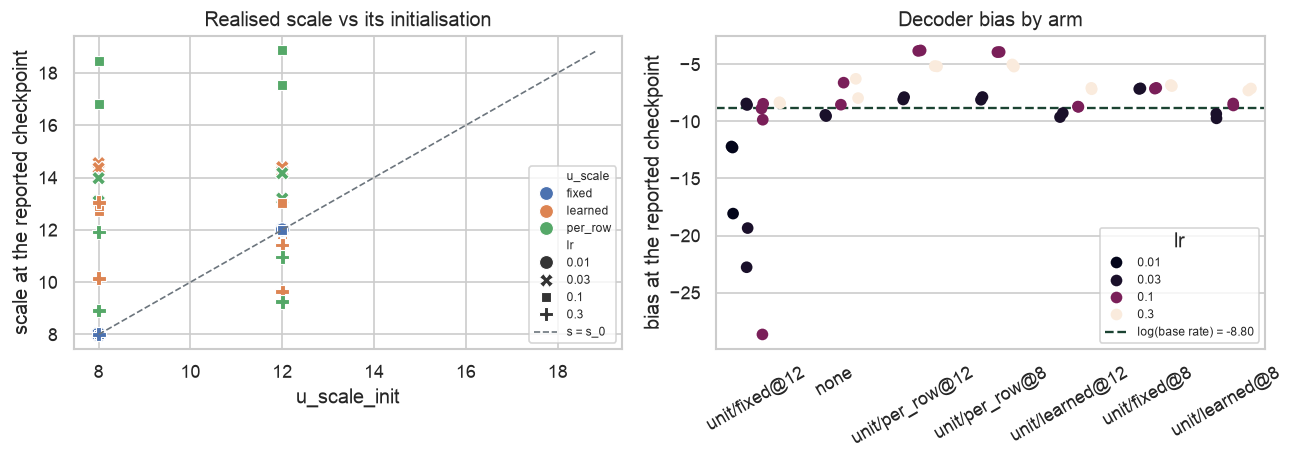

learned scale at the reported checkpoint, from initialisations 8, 12:
  lr=0.03: 14.25–14.55 over 4 run(s)
  lr=0.1: 11.84–13.02 over 4 run(s)
  lr=0.3: 9.63–13.05 over 4 run(s)
best fixed scale by held-out likelihood: s=12 at lr=0.01


u_scale_value  u_scale_value_max  decoder_bias  \
u_scale u_scale_init lr                                                     
fixed   8.0          0.03          8.000              8.000        -7.126   
                     0.10          8.000              8.000        -7.090   
                     0.30          8.000              8.000        -6.855   
        12.0         0.01         12.000             12.000       -14.186   
                     0.03         12.000             12.000       -14.776   
                     0.10         12.000             12.000       -13.959   
                     0.30         12.000             12.000        -8.364   
learned 8.0          0.03         14.453             14.453        -9.532   
                     0.10         12.803             12.803        -8.515   
                     0.30         11.599             11.599        -7.200   
        12.0         0.03         14.324             14.324        -9.441   
                     0.10         12.427             12.427        -8.710   
                     0.30         10.530             10.530        -7.117   
per_row 8.0          0.03         13.528             23.200        -7.979   
                     0.10         17.636             41.875        -3.918   
                     0.30         10.413             31.706        -5.098   
        12.0         0.03         13.678             23.277        -7.973   
                     0.10         18.207             34.470        -3.797   
                     0.30         10.105             33.005        -5.160   

                           max_abs_train_logit  gt_hungarian  
u_scale u_scale_init lr                                       
fixed   8.0          0.03               13.136      22956.50  
                     0.10               13.075      14766.50  
                     0.30               13.768       5603.00  
        12.0         0.01               44.123       4743.00  
                     0.03               33.092      17095.00  
                     0.10               28.828      14007.75  
                     0.30               19.114       5178.50  
learned 8.0          0.03               17.793      21554.00  
                     0.10               18.275      15174.50  
                     0.30               19.580       7686.50  
        12.0         0.03               17.195      22082.50  
                     0.10               18.258      16577.50  
                     0.30               18.412       7795.00  
per_row 8.0          0.03               18.376      23334.00  
                     0.10               96.041      15888.50  
                     0.30             4128.638       6242.00  
        12.0         0.03               20.915      22634.50  
                     0.10               74.922      17094.50  
                     0.30              746.212       7219.50

In [40]:
# Where the scale settles, and where the bias settles. The learned scale is the
# diagnostic that reports whether the fixed scale was badly chosen: if it converges
# above every initialisation, the grid did not contain a large enough s. The bias is
# the only unbounded term left in the decoder, and it should stay near log(base rate)
# unless the scale is too tight to express the block densities.
if con.empty:
    print("no constraint runs: skipping the scale and bias panels")
else:
    scaled = con[con["u_scale_value"].notna()] if "u_scale_value" in con.columns else con.iloc[:0]
    panels = int(not scaled.empty) + int("decoder_bias" in con.columns)
    if panels == 0:
        print("neither u_scale_value nor decoder_bias is recorded: skipping")
    else:
        fig, axes = plt.subplots(1, panels, figsize=(5.5 * panels, 4.0))
        axes = np.atleast_1d(axes)
        i = 0
        if not scaled.empty:
            ax = axes[i]
            i += 1
            sns.scatterplot(
                data=scaled, x="u_scale_init", y="u_scale_value",
                hue="u_scale", style="lr", s=70, ax=ax,
            )
            lo = float(min(scaled["u_scale_init"].min(), scaled["u_scale_value"].min()))
            hi = float(max(scaled["u_scale_init"].max(), scaled["u_scale_value"].max()))
            ax.plot([lo, hi], [lo, hi], color="#6c757d", ls="--", lw=1.0, label="s = s_0")
            ax.set_title("Realised scale vs its initialisation")
            ax.set_xlabel("u_scale_init")
            ax.set_ylabel("scale at the reported checkpoint")
            ax.legend(fontsize=7)
        if "decoder_bias" in con.columns:
            ax = axes[i]
            sns.stripplot(
                data=con.sort_values("lr"), x="arm", y="decoder_bias",
                hue="lr", dodge=True, palette="rocket", ax=ax, size=7,
            )
            try:
                import scipy.sparse as sp

                a = sp.load_npz("sparse_connectivity_matrix.npz")
                n = a.shape[0]
                base_rate = a.nnz / (n * (n - 1))
                ax.axhline(
                    np.log(base_rate), color="#1b4332", ls="--", lw=1.4,
                    label=f"log(base rate) = {np.log(base_rate):.2f}",
                )
            except Exception as exc:  # adjacency is optional for plotting
                print(f"could not compute the base rate ({exc}); bias reference line omitted")
            ax.set_title("Decoder bias by arm")
            ax.set_xlabel("")
            ax.set_ylabel("bias at the reported checkpoint")
            ax.tick_params(axis="x", rotation=30)
            ax.legend(fontsize=7, title="lr")
        plt.tight_layout()
        plt.show()

    if not scaled.empty:
        learned = scaled[scaled["u_scale"] == "learned"]
        if not learned.empty:
            inits = ", ".join(f"{v:g}" for v in sorted(learned["u_scale_init"].unique()))
            print(f"learned scale at the reported checkpoint, from initialisations {inits}:")
            for lr, sub in learned.groupby("lr"):
                print(
                    f"  lr={lr:g}: {sub['u_scale_value'].min():.2f}–"
                    f"{sub['u_scale_value'].max():.2f} over {len(sub)} run(s)"
                )
            best_fixed = con[con["u_scale"] == "fixed"].sort_values("val_metric").tail(1)
            if not best_fixed.empty:
                lr_best = float(best_fixed["lr"].iloc[0])
                at_lr = learned[learned["lr"] == lr_best]["u_scale_value"]
                print(
                    "best fixed scale by held-out likelihood: "
                    f"s={best_fixed['u_scale_init'].iloc[0]:g} at lr={lr_best:g}"
                    + (
                        f", where the learned scale converges to "
                        f"{at_lr.min():.2f}–{at_lr.max():.2f}: fixed scales above "
                        f"{best_fixed['u_scale_init'].iloc[0]:g} are untested"
                        if not at_lr.empty
                        else ""
                    )
                )
        display(
            scaled.groupby(["u_scale", "u_scale_init", "lr"])[
                [c for c in ["u_scale_value", "u_scale_value_max", "decoder_bias",
                             "max_abs_train_logit", "gt_hungarian"] if c in scaled.columns]
            ]
            .mean()
            .round(3)
        )

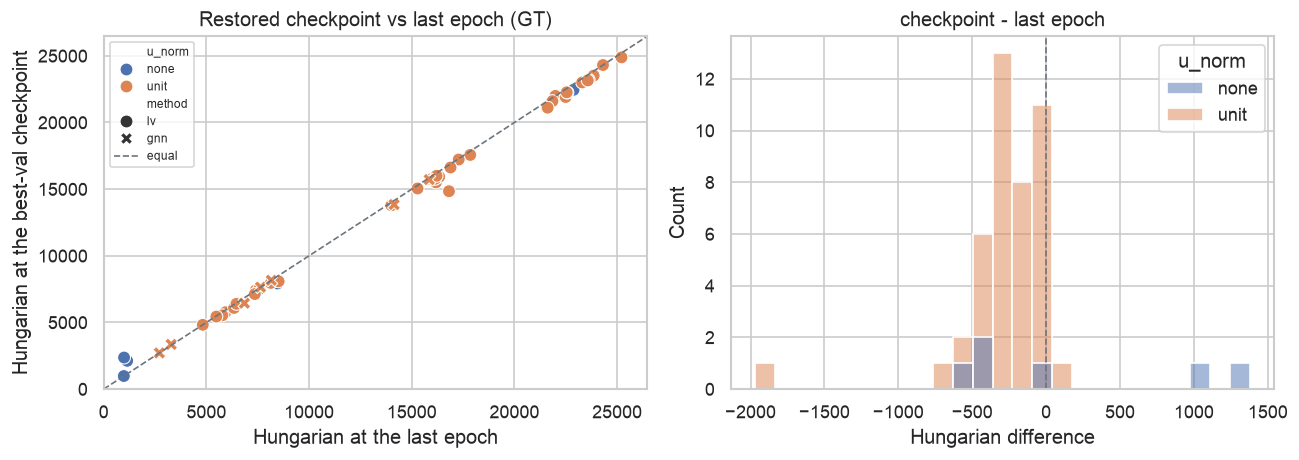

best-val checkpoint scores WORSE on ground truth in 38/49 run(s); mean difference -212.3 Hungarian (-1.43% of the last epoch, median)
runs the checkpoint rescued (large positive deltas are collapsed runs):


,name,u_norm,d,lr,val_auc,gt_hungarian,last_gt_hungarian,delta
28,hp_lv_d256_lr0.1_bfs1.0_bernoulli,none,256,0.10,0.761065,2368.0,991.0,1377.0
14,hp_lv_d64_lr0.3_bfs1.0_bernoulli,none,64,0.30,0.345647,2120.0,1143.0,977.0
53,hp_gnn_L1_d64_lr0.01_bfs1.0_bernoulli_unit_fix...,unit,64,0.01,0.988995,3355.0,3285.0,70.0
52,hp_gnn_L1_d64_lr0.1_bfs1.0_bernoulli_unit_fixe...,unit,64,0.10,0.981686,7646.0,7639.0,7.0
49,hp_gnn_L2_d64_lr0.01_bfs1.0_bernoulli_unit_fix...,unit,64,0.01,0.989293,2712.0,2710.0,2.0


label_smoothing takes a single value in this sweep (0); the smoothing panel needs at least two to compare


In [41]:
# Best-validation checkpoint against last epoch, on ground truth, same seed and same
# budget. The checkpoint machinery exists to salvage diverged runs; on a training curve
# that no longer collapses it gives up a little agreement instead, and the sign of that
# trade is systematic rather than noisy.
if "last_gt_hungarian" not in hp.columns:
    print("no last_gt_hungarian column: skipping the checkpoint-versus-last-epoch panel")
else:
    both = hp[hp["gt_hungarian"].notna() & hp["last_gt_hungarian"].notna()].copy()
    both["delta"] = both["gt_hungarian"] - both["last_gt_hungarian"]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
    hue = "u_norm" if "u_norm" in both.columns and both["u_norm"].notna().any() else "method"
    sns.scatterplot(
        data=both, x="last_gt_hungarian", y="gt_hungarian",
        hue=hue, style="method", s=60, ax=axes[0],
    )
    lim = [0, float(both[["gt_hungarian", "last_gt_hungarian"]].to_numpy().max()) * 1.05]
    axes[0].plot(lim, lim, color="#6c757d", ls="--", lw=1.0, label="equal")
    axes[0].set_xlim(lim)
    axes[0].set_ylim(lim)
    axes[0].set_title("Restored checkpoint vs last epoch (GT)")
    axes[0].set_xlabel("Hungarian at the last epoch")
    axes[0].set_ylabel("Hungarian at the best-val checkpoint")
    axes[0].legend(fontsize=7)
    sns.histplot(data=both, x="delta", hue=hue, bins=25, ax=axes[1])
    axes[1].axvline(0.0, color="#6c757d", ls="--", lw=1.0)
    axes[1].set_title("checkpoint - last epoch")
    axes[1].set_xlabel("Hungarian difference")
    plt.tight_layout()
    plt.show()

    worse = both[both["delta"] < 0]
    median_pct = 100 * (both["delta"] / both["last_gt_hungarian"]).median()
    print(
        f"best-val checkpoint scores WORSE on ground truth in {len(worse)}/{len(both)} run(s); "
        f"mean difference {both['delta'].mean():+.1f} Hungarian "
        f"({median_pct:+.2f}% of the last epoch, median)"
    )
    rescued = both[both["delta"] > 0].sort_values("delta", ascending=False)
    if not rescued.empty:
        print("runs the checkpoint rescued (large positive deltas are collapsed runs):")
        display(
            rescued[[c for c in ["name", "u_norm", "d", "lr", "val_auc", "gt_hungarian",
                                 "last_gt_hungarian", "delta"] if c in rescued.columns]].head(10)
        )

# Label smoothing, when a sweep varied it. At lr=0.1 it changed nothing: every arm
# collapsed to the same saturated likelihood, because the optimiser overshoots any
# finite target by a factor of several hundred rather than walking towards it.
if "label_smoothing" not in hp.columns or hp["label_smoothing"].dropna().nunique() < 2:
    values = (
        [f"{v:g}" for v in sorted(hp["label_smoothing"].dropna().unique())]
        if "label_smoothing" in hp.columns
        else []
    )
    print(
        f"label_smoothing takes a single value in this sweep ({', '.join(values) or 'none'}); "
        "the smoothing panel needs at least two to compare"
    )
else:
    ls = hp[hp["label_smoothing"].notna()].copy()
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
    sns.stripplot(data=ls, x="label_smoothing", y="gt_hungarian", hue="lr", dodge=True, ax=axes[0])
    axes[0].set_title("Hungarian vs label smoothing eps")
    sns.stripplot(data=ls, x="label_smoothing", y="val_metric", hue="lr", dodge=True, ax=axes[1])
    axes[1].set_title("held-out LL vs label smoothing eps")
    plt.tight_layout()
    plt.show()
    by = ["label_smoothing"]
    if "label_smoothing_target" in ls.columns:
        by.append("label_smoothing_target")
    wanted = ["val_metric", "val_auc", "gt_hungarian", "max_abs_train_logit"]
    shown = [c for c in wanted if c in ls.columns]
    display(ls.groupby(by)[shown].mean().round(4))

## 2b. Negative results (kept in old tables only)

Per-neuron residuals ($e_i$) and GNN residuals improved held-out edge likelihood
and **hurt** cell-type recovery. Their trainers are no longer in the tree; see
the README section *What did not matter*. If an older `hp_results.csv` still
contains `lv_e` / `gnn` rows, the cell below will show the residual-to-bilinear
ratio that made the failure mode visible. On a clean LV-only table it is a no-op.


,name,layers,lr,resid_ratio,val_metric,val_auc,gt_hungarian
55,hp_gnn_L0_d64_lr0.1_bfs1.0_bernoulli_unit_fixe...,0.0,0.10,0.360529,-1.554279,0.977430,15715.0
50,hp_gnn_L0_d64_lr0.03_bfs1.0_bernoulli_unit_fix...,0.0,0.03,0.593995,-1.202311,0.991117,13842.0
54,hp_gnn_L0_d64_lr0.01_bfs1.0_bernoulli_unit_fix...,0.0,0.01,0.645608,-1.349913,0.988079,8162.0
51,hp_gnn_L1_d64_lr0.03_bfs1.0_bernoulli_unit_fix...,1.0,0.03,0.846419,-1.244560,0.990103,6444.0
52,hp_gnn_L1_d64_lr0.1_bfs1.0_bernoulli_unit_fixe...,1.0,0.10,0.863671,-1.258851,0.981686,7646.0
49,hp_gnn_L2_d64_lr0.01_bfs1.0_bernoulli_unit_fix...,2.0,0.01,0.992860,-1.154408,0.989293,2712.0
53,hp_gnn_L1_d64_lr0.01_bfs1.0_bernoulli_unit_fix...,1.0,0.01,1.009270,-1.262641,0.988995,3355.0


  gnn: spearman(resid/bilinear vs gt_hungarian) = -0.929
  gnn: spearman(resid/bilinear vs val_metric  ) = +0.357
  gnn: spearman(layers vs gt_hungarian        ) = -0.926
  gnn: spearman(lr vs gt_hungarian            ) = +0.605


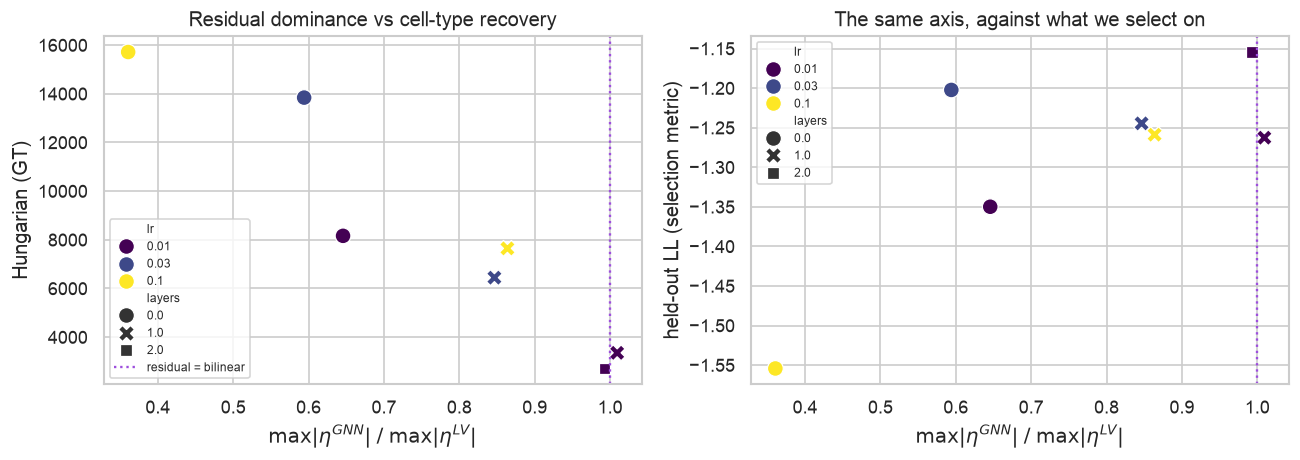

gnn: selecting on val_metric costs 13,003 Hungarian (5.8x)
    picked  hp_gnn_L2_d64_lr0.01_bfs1.0_bernoulli_unit_fixed12.0_gnnunit: val=-1.154 hung=2,712
    GT-best hp_gnn_L0_d64_lr0.1_bfs1.0_bernoulli_unit_fixed12.0_gnnunit: val=-1.554 hung=15,715


In [42]:
# Does the residual out-compete the bilinear term, and does that track the loss of
# cell-type structure? Only the GNN carries a residual, so this is a no-op elsewhere.
RESID, BILIN = "max_abs_train_residual", "max_abs_train_lv_logit"

if {RESID, BILIN}.issubset(hp.columns) and hp[RESID].notna().any():
    res = hp[hp[RESID].notna() & hp[BILIN].notna() & (hp[BILIN] > 0)].copy()
    res["resid_ratio"] = res[RESID] / res[BILIN]

    for method, sub in res.groupby("method"):
        cols = [c for c in ["name", "layers", "lr", "resid_ratio", "val_metric",
                            "val_auc", "gt_hungarian"] if c in sub.columns]
        display(sub.sort_values("resid_ratio")[cols])

        if len(sub) > 2:
            # A strong negative rho against Hungarian, alongside a non-negative one
            # against val_metric, is the bypass: the residual buys likelihood and
            # spends ground truth.
            pairs = [("resid/bilinear vs gt_hungarian",
                      sub["resid_ratio"].corr(sub["gt_hungarian"], method="spearman")),
                     ("resid/bilinear vs val_metric",
                      sub["resid_ratio"].corr(sub["val_metric"], method="spearman"))]
            # The grid axes, for comparison: if the ratio is the mechanism it should
            # explain at least as much as the knobs that produced it.
            pairs += [
                (f"{axis} vs gt_hungarian",
                 sub[axis].corr(sub["gt_hungarian"], method="spearman"))
                for axis in ("layers", "lr")
                if axis in sub.columns and sub[axis].notna().any()
            ]
            width = max(len(label) for label, _ in pairs)
            for label, rho in pairs:
                print(f"  {method}: spearman({label.ljust(width)}) = {rho:+.3f}")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    style = "layers" if "layers" in res.columns and res["layers"].notna().any() else None
    sns.scatterplot(data=res, x="resid_ratio", y="gt_hungarian", hue="lr",
                    style=style, s=90, palette="viridis", ax=axes[0])
    # At ratio 1 the residual is as large as the term the constraint bounds.
    axes[0].axvline(1.0, color="#9d4edd", ls=":", lw=1.4, label="residual = bilinear")
    axes[0].set_xlabel(r"$\max|\eta^{GNN}| \; / \; \max|\eta^{LV}|$")
    axes[0].set_ylabel("Hungarian (GT)")
    axes[0].set_title("Residual dominance vs cell-type recovery")
    axes[0].legend(fontsize=7)

    sns.scatterplot(data=res, x="resid_ratio", y="val_metric", hue="lr",
                    style=style, s=90, palette="viridis", ax=axes[1])
    axes[1].axvline(1.0, color="#9d4edd", ls=":", lw=1.4)
    axes[1].set_xlabel(r"$\max|\eta^{GNN}| \; / \; \max|\eta^{LV}|$")
    axes[1].set_ylabel("held-out LL (selection metric)")
    axes[1].set_title("The same axis, against what we select on")
    axes[1].legend(fontsize=7)
    plt.tight_layout()
    plt.show()

    # What selecting on val_metric actually costs, in the units we care about.
    for method, sub in res.groupby("method"):
        if len(sub) < 2:
            continue
        picked = sub.loc[sub["val_metric"].idxmax()]
        truth = sub.loc[sub["gt_hungarian"].idxmax()]
        if picked["name"] == truth["name"]:
            print(f"{method}: val_metric selects the ground-truth optimum.")
            continue
        gap = truth["gt_hungarian"] - picked["gt_hungarian"]
        factor = truth["gt_hungarian"] / max(picked["gt_hungarian"], 1e-9)
        print(
            f"{method}: selecting on val_metric costs {gap:,.0f} Hungarian "
            f"({factor:.1f}x)\n"
            f"    picked  {picked['name']}: "
            f"val={picked['val_metric']:.3f} hung={picked['gt_hungarian']:,.0f}\n"
            f"    GT-best {truth['name']}: "
            f"val={truth['val_metric']:.3f} hung={truth['gt_hungarian']:,.0f}"
        )
else:
    print("No residual diagnostics in this sweep (GNN runs only); skipping.")

## 2c. Capacity: how far does widening $d$ go?

$d$ is the rank of the block decoder, not a per-node width: the assignment table
is $n \times K$ regardless, so widening $d$ costs almost nothing and buys a
richer $K \times K$ block matrix. The question is whether the block structure was
ever rank-limited.

Extra rank is capacity for *edge* prediction. If held-out likelihood keeps
improving with $d$ while ground truth turns over, the selector is buying
likelihood with cell types — another reminder that the unsupervised objective
is only a proxy.


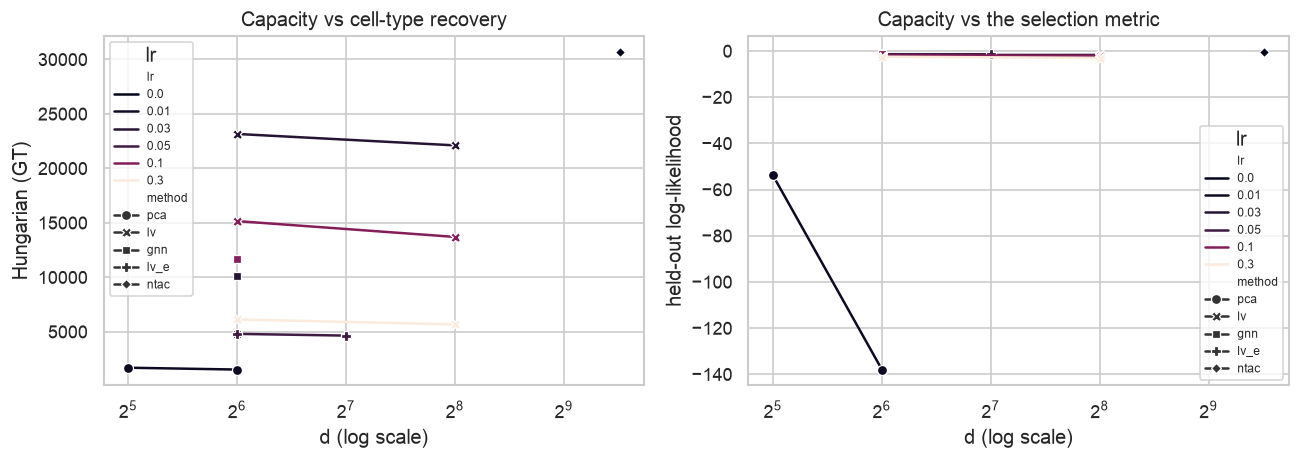

,d,lr,val_metric,val_auc,gt_hungarian,max_abs_train_logit,u_scale_value
0,729,0.00,-0.480313,NaN,30672.0,NaN,NaN
1,32,0.01,-53.905715,NaN,1692.0,NaN,NaN
2,64,0.01,-137.972423,NaN,1523.0,NaN,NaN
3,64,0.01,-1.154408,0.989293,2712.0,43.119949,12.000000
4,64,0.01,-1.262641,0.988995,3355.0,45.606018,12.000000
5,64,0.01,-1.349913,0.988079,8162.0,43.643936,12.000000
6,64,0.03,-1.745659,0.973504,22451.0,39.605515,NaN
7,64,0.03,-1.715824,0.976683,24311.0,13.039191,8.000000
8,64,0.03,-1.684145,0.977729,24886.0,16.600861,12.000000
9,64,0.03,-1.697204,0.976392,21996.0,18.866978,14.547102


Spearman rho with d, within each learning rate:

rho(val_metric) > 0 with rho(gt_hungarian) < 0 is the bypass signature: rank is being spent on edges rather than on cell types.


In [43]:
# Ground truth and held-out likelihood against d, on one x-axis, per learning rate.
# Both are plotted because the interesting outcome is them disagreeing.
cap = hp[hp["d"].notna()].copy() if "d" in hp.columns else hp.iloc[:0].copy()

if cap.empty or cap["d"].nunique() < 3:
    print("fewer than three distinct d values: skipping the capacity panels")
else:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
    for ax, (ycol, ylabel) in zip(
        axes,
        [("gt_hungarian", "Hungarian (GT)"), ("val_metric", "held-out log-likelihood")],
    ):
        sns.lineplot(
            data=cap.sort_values("d"), x="d", y=ycol, hue="lr", style="method",
            markers=True, dashes=False, ax=ax, errorbar=None, palette="rocket",
        )
        ax.set_xscale("log", base=2)
        ax.set_xlabel("d (log scale)")
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=7, title="lr")
    axes[0].set_title("Capacity vs cell-type recovery")
    axes[1].set_title("Capacity vs the selection metric")
    plt.tight_layout()
    plt.show()

    table_cols = [
        c for c in ["d", "lr", "val_metric", "val_auc", "gt_hungarian",
                    "max_abs_train_logit", "u_scale_value"]
        if c in cap.columns
    ]
    display(cap.sort_values(["lr", "d"])[table_cols].reset_index(drop=True))

    # Per learning rate, so the trend in d is not confounded by the optimiser: a
    # width that only looks bad because its step size was tuned elsewhere is an
    # optimisation result, not a capacity result.
    print("Spearman rho with d, within each learning rate:")
    for lr, sub in cap.groupby("lr"):
        if sub["d"].nunique() < 3:
            continue
        rho_gt = sub["d"].corr(sub["gt_hungarian"], method="spearman")
        rho_ll = sub["d"].corr(sub["val_metric"], method="spearman")
        best_d = sub.loc[sub["gt_hungarian"].idxmax(), "d"]
        sel_d = sub.loc[sub["val_metric"].idxmax(), "d"]
        print(
            f"  lr={lr:<7g} n={len(sub):2d}  gt_hungarian {rho_gt:+.3f}  "
            f"val_metric {rho_ll:+.3f}   best-GT d={best_d:g}  selected d={sel_d:g}"
        )
    print(
        "\nrho(val_metric) > 0 with rho(gt_hungarian) < 0 is the bypass signature: "
        "rank is being spent on edges rather than on cell types."
    )

## 3. Multi-seed uncertainty (final runs)

Hungarian / ARI / NMI over final seeds for the selected HP of each method.
Alongside accuracy we report $K_{\mathrm{pred}}$: the number of **distinct predicted
clusters on the labelled shared neurons** (`gt_n_pred_clusters`). When that differs
across methods (NTAC is typically coarser than LV), Hungarian remains a well-defined
count of correctly typed neurons under optimal 1–1 matching, but it is *not*
resolution-matched — under-clustering can look strong by recovering large types well.
Always read Hungarian next to $K_{\mathrm{pred}}$ / `gt_n_pred_clusters` (GT has $K=729$ types).


In [44]:
from evaluate_clustering import (
    align_assignments,
    encode_labels,
    load_assignment_dict,
    load_ground_truth,
    random_assignment_baseline,
)

final = attach_val_auc(pd.read_csv("final_results.csv"))
summary = pd.read_csv("final_summary.csv")
display(summary)

# Methods present in HP tables but absent from finals (e.g. interrupted sweeps).
missing = [m for m in methods_present(hp) if m not in set(final["method"].unique())]
if missing:
    print(
        f"In the HP tables but NOT in the finals: {', '.join(missing)} "
        "— single-seed HP runs only, no multi-seed uncertainty."
    )
if "partial" in hp.columns and hp["partial"].fillna(False).astype(bool).any():
    part = hp[hp["partial"].fillna(False).astype(bool)]
    print(
        f"Reconstructed from an interrupted sweep: {len(part)} row(s) across "
        f"{', '.join(sorted(part['method'].unique()))} — the matching hp_best is the "
        "best of what ran, not of what was asked for."
    )
display(final.sort_values(["method", "seed"])[[c for c in HP_COLS if c in final.columns] + ["seed"]])

# K_pred on the labelled set (what Hungarian actually sees). Prefer gt_n_pred_clusters;
# fall back to n_pred_clusters if an older table only has the full-graph count.
_kcol = next((c for c in ("gt_n_pred_clusters", "n_pred_clusters") if c in final.columns), None)
if _kcol is None:
    print("No K_pred column in final_results.csv")
else:
    k_tbl = (
        final.groupby("method", sort=False)[_kcol]
        .agg(k_pred_mean="mean", k_pred_std="std", k_pred_min="min", k_pred_max="max", n_seeds="count")
        .reset_index()
    )
    if "gt_n_gt_clusters" in final.columns:
        k_tbl["k_gt"] = final.groupby("method")["gt_n_gt_clusters"].first().reindex(k_tbl["method"]).values
    print(f"K_pred = {_kcol} (distinct predicted clusters on labelled neurons):")
    display(k_tbl)

# Random baseline + theoretical max on the same shared GT set as the finals.
gt = load_ground_truth(Path("root_id_type_dict.pkl"))
pred_paths = sorted(Path(".").glob("final_*_assignment_dict*.npy"))
if pred_paths:
    pred0 = load_assignment_dict(pred_paths[0])
    gt_labels, _, shared = align_assignments(pred0, gt)
else:
    gt_labels, _ = encode_labels(list(gt.values()))
    shared = list(gt.keys())

k_pred = 729
rand_base = random_assignment_baseline(gt_labels, k=k_pred, n_seeds=20, seed=0)
print(
    f"Random (K={k_pred}, n={len(shared)}, 20 seeds): "
    f"Hungarian {rand_base['hungarian_mean']:.1f} ± {rand_base['hungarian_std']:.1f} "
    f"| ARI {rand_base['ari_mean']:.4f} ± {rand_base['ari_std']:.4f} "
    f"| NMI {rand_base['nmi_mean']:.4f} ± {rand_base['nmi_std']:.4f}"
)
print(
    f"Theoretical max (perfect recovery): Hungarian {rand_base['hungarian_max']:.0f}, "
    f"ARI {rand_base['ari_max']:.0f}, NMI {rand_base['nmi_max']:.0f}"
)

,ari_mean,ari_std,hp_bfs_frac,hp_d,hp_d_e,hp_e_wd,hp_frac_seeds,hp_label_smoothing,hp_likelihood,hp_lr,...,hungarian_best_minus_last,hungarian_mean,hungarian_std,last_hungarian_mean,last_hungarian_std,method,n_seeds,nmi_mean,nmi_std,selection_val_metric
0,0.487877,0.041267,1.0,256,NaN,NaN,NaN,0.0,bernoulli,0.03,...,-183.666667,24300.000000,971.636249,24483.666667,770.299509,lv,3,0.822152,0.006770,-1.665582
1,0.041721,0.002472,1.0,64,16.0,0.01,NaN,NaN,poisson,0.05,...,NaN,5216.333333,89.198281,NaN,NaN,lv_e,3,0.372948,0.001916,-1.397446
2,0.675656,0.005929,NaN,729,NaN,NaN,0.1,NaN,NaN,0.00,...,NaN,30654.500000,24.748737,NaN,NaN,ntac,2,0.878414,0.001537,-0.480313
3,0.008135,0.002646,NaN,32,NaN,NaN,NaN,NaN,NaN,0.01,...,NaN,1355.000000,88.831301,NaN,NaN,pca,3,0.224727,0.008043,-53.905715


In the HP tables but NOT in the finals: gnn — single-seed HP runs only, no multi-seed uncertainty.
Reconstructed from an interrupted sweep: 7 row(s) across gnn — the matching hp_best is the best of what ran, not of what was asked for.


,name,method,d,lr,likelihood,bfs_frac,d_e,e_wd,u_norm,u_scale,u_scale_init,label_smoothing,val_metric,val_auc,gt_hungarian,gt_ari,gt_nmi,seed
0,final_lv_d256_lr0.03_bfs1.0_bernoulli_unit_fix...,lv,256,0.03,bernoulli,1.0,NaN,NaN,unit,fixed,12.0,0.0,-1.665582,0.978600,23208.0,0.440381,0.821575,0
1,final_lv_d256_lr0.03_bfs1.0_bernoulli_unit_fix...,lv,256,0.03,bernoulli,1.0,NaN,NaN,unit,fixed,12.0,0.0,-1.661637,0.979334,24623.0,0.508303,0.829193,1
2,final_lv_d256_lr0.03_bfs1.0_bernoulli_unit_fix...,lv,256,0.03,bernoulli,1.0,NaN,NaN,unit,fixed,12.0,0.0,-1.628425,0.980280,25069.0,0.514947,0.815689,2
3,final_lv_e_d64_de16_lr0.05_ewd0.01_bfs1.0_pois...,lv_e,64,0.05,poisson,1.0,16.0,0.01,NaN,NaN,NaN,NaN,-1.232121,0.992163,5144.0,0.038998,0.371004,0
4,final_lv_e_d64_de16_lr0.05_ewd0.01_bfs1.0_pois...,lv_e,64,0.05,poisson,1.0,16.0,0.01,NaN,NaN,NaN,NaN,-1.194342,0.992594,5189.0,0.042341,0.374835,1
5,final_lv_e_d64_de16_lr0.05_ewd0.01_bfs1.0_pois...,lv_e,64,0.05,poisson,1.0,16.0,0.01,NaN,NaN,NaN,NaN,-1.219985,0.992179,5316.0,0.043823,0.373006,2
9,final_ntac_k729_R12_T0.1_seed0,ntac,729,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.480313,NaN,30672.0,0.679849,0.879501,0
10,final_ntac_k729_R12_T0.1_seed1,ntac,729,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.482294,NaN,30637.0,0.671464,0.877327,1
6,final_pca_d32_lr0.01_seed0,pca,32,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.480807,NaN,1369.0,0.009491,0.219383,0
7,final_pca_d32_lr0.01_seed1,pca,32,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-5.363856,NaN,1436.0,0.009829,0.220821,1


Random (K=729, n=46479, 20 seeds): Hungarian 980.0 ± 8.0 | ARI 0.0000 ± 0.0000 | NMI 0.2015 ± 0.0003
Theoretical max (perfect recovery): Hungarian 46479, ARI 1, NMI 1


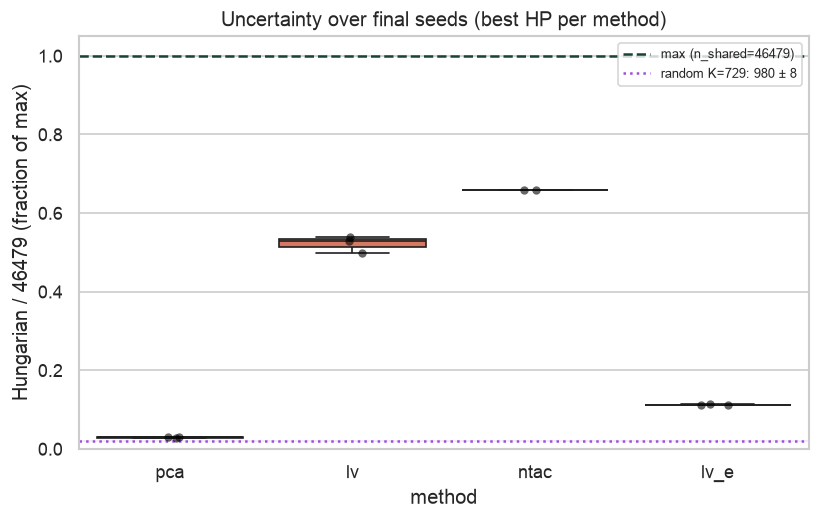

ntac (n_seeds=2): Hungarian 30654.5 ± 24.7 (65.95% of max); ARI 0.676 ± 0.006, NMI 0.878 ± 0.002
lv (n_seeds=3): Hungarian 24300.0 ± 971.6 (52.28% of max); ARI 0.488 ± 0.041, NMI 0.822 ± 0.007
lv_e (n_seeds=3): Hungarian 5216.3 ± 89.2 (11.22% of max); ARI 0.042 ± 0.002, NMI 0.373 ± 0.002
pca (n_seeds=3): Hungarian 1355.0 ± 88.8 (2.92% of max); ARI 0.008 ± 0.003, NMI 0.225 ± 0.008
note: seed budgets differ across methods ({'lv': 3, 'lv_e': 3, 'ntac': 2, 'pca': 3}); dispersion is not directly comparable
random: Hungarian 980.0 ± 8.0 (2.11% of max); ARI 0.000 ± 0.000, NMI 0.202 ± 0.000
max:    Hungarian 46479 (100%; ARI/NMI = 1)
lv: checkpoint 24300 vs last epoch 24484 (-184)
Selected hyperparameters behind each finals row:


,hp_bfs_frac,hp_d,hp_d_e,hp_e_wd,hp_frac_seeds,hp_label_smoothing,hp_likelihood,hp_lr,hp_max_iterations,hp_max_k,hp_u_norm,hp_u_scale,hp_u_scale_init
method,,,,,,,,,,,,,
lv,1.0,256,NaN,NaN,NaN,0.0,bernoulli,0.03,NaN,NaN,unit,fixed,12.0
lv_e,1.0,64,16.0,0.01,NaN,NaN,poisson,0.05,NaN,NaN,NaN,NaN,NaN
ntac,NaN,729,NaN,NaN,0.1,NaN,NaN,0.00,12.0,729.0,NaN,NaN,NaN
pca,NaN,32,NaN,NaN,NaN,NaN,NaN,0.01,NaN,NaN,NaN,NaN,NaN


In [45]:
# Plot as fraction of theoretical max so random + ceiling are on-scale.
n_shared = float(rand_base["hungarian_max"])
plot_df = final.copy()
plot_df["hungarian_frac"] = plot_df["gt_hungarian"] / n_shared
rand_frac = rand_base["hungarian_mean"] / n_shared
rand_frac_std = rand_base["hungarian_std"] / n_shared

fig, ax = plt.subplots(figsize=(7, 4.5))
# Grouped finals are their own arms and must not be pooled into their method.
gcol = group_col(plot_df)
order = groups_present(plot_df)
palette = group_palette(plot_df, order)
sns.boxplot(
    data=plot_df, x=gcol, y="hungarian_frac", order=order,
    hue=gcol, palette=palette, legend=False, ax=ax,
)
sns.stripplot(
    data=plot_df, x=gcol, y="hungarian_frac", order=order,
    color="black", alpha=0.6, ax=ax,
)
ax.axhline(1.0, color="#1b4332", ls="--", lw=1.5, label=f"max (n_shared={n_shared:.0f})")
ax.axhline(
    rand_frac,
    color="#9d4edd",
    ls=":",
    lw=1.5,
    label=f"random K={k_pred}: {rand_base['hungarian_mean']:.0f} ± {rand_base['hungarian_std']:.0f}",
)
ax.axhspan(
    rand_frac - rand_frac_std,
    rand_frac + rand_frac_std,
    color="#9d4edd",
    alpha=0.12,
    zorder=0,
)
ax.set_ylim(0, 1.05)
ax.set_ylabel(f"Hungarian / {n_shared:.0f} (fraction of max)")
ax.set_title("Uncertainty over final seeds (best HP per method)")
ax.tick_params(axis="x", rotation=20 if len(order) > 5 else 0)
ax.legend(loc="upper right", fontsize=8, frameon=True)
plt.tight_layout()
plt.show()

# K_pred beside Hungarian: same seeds, so unequal K is visible rather than buried.
_kcol = next((c for c in ("gt_n_pred_clusters", "n_pred_clusters") if c in plot_df.columns), None)
if _kcol is not None:
    fig, ax = plt.subplots(figsize=(7, 3.8))
    sns.boxplot(
        data=plot_df, x=gcol, y=_kcol, order=order,
        hue=gcol, palette=palette, legend=False, ax=ax,
    )
    sns.stripplot(
        data=plot_df, x=gcol, y=_kcol, order=order,
        color="black", alpha=0.6, ax=ax,
    )
    k_gt = float(plot_df["gt_n_gt_clusters"].dropna().iloc[0]) if "gt_n_gt_clusters" in plot_df.columns and plot_df["gt_n_gt_clusters"].notna().any() else 729.0
    ax.axhline(k_gt, color="#1b4332", ls="--", lw=1.5, label=f"K_gt={k_gt:.0f}")
    ax.set_ylabel(r"$K_{\mathrm{pred}}$ (labelled neurons)")
    ax.set_title("Occupied clusters on the labelled set")
    ax.tick_params(axis="x", rotation=20 if len(order) > 5 else 0)
    ax.legend(loc="best", fontsize=8, frameon=True)
    plt.tight_layout()
    plt.show()

summary_gcol = group_col(summary)
# Attach K_pred mean±std from the seed-level finals (summary.csv may lack it).
_kcol = next((c for c in ("gt_n_pred_clusters", "n_pred_clusters") if c in final.columns), None)
_k_by = {}
if _kcol is not None:
    for method, sub in final.groupby(group_col(final)):
        vals = sub[_kcol].dropna().astype(float)
        if len(vals):
            _k_by[method] = (float(vals.mean()), float(vals.std(ddof=1)) if len(vals) > 1 else 0.0)

for _, row in summary.sort_values("hungarian_mean", ascending=False).iterrows():
    key = row[summary_gcol]
    k_txt = ""
    if key in _k_by:
        km, ks = _k_by[key]
        k_txt = f"K_pred {km:.0f} ± {ks:.0f}; "
    print(
        f"{key} (n_seeds={int(row['n_seeds'])}): "
        f"{k_txt}"
        f"Hungarian {row['hungarian_mean']:.1f} ± {row['hungarian_std']:.1f} "
        f"({100 * row['hungarian_mean'] / n_shared:.2f}% of max); "
        f"ARI {row['ari_mean']:.3f} ± {row['ari_std']:.3f}, "
        f"NMI {row['nmi_mean']:.3f} ± {row['nmi_std']:.3f}"
    )
n_seed_counts = summary.set_index(summary_gcol)["n_seeds"].astype(int).to_dict()
if len(set(n_seed_counts.values())) > 1:
    print(
        f"note: seed budgets differ across methods ({n_seed_counts}); "
        "dispersion is not directly comparable"
    )
print(
    f"random: Hungarian {rand_base['hungarian_mean']:.1f} ± {rand_base['hungarian_std']:.1f} "
    f"({100 * rand_frac:.2f}% of max); "
    f"ARI {rand_base['ari_mean']:.3f} ± {rand_base['ari_std']:.3f}, "
    f"NMI {rand_base['nmi_mean']:.3f} ± {rand_base['nmi_std']:.3f}"
)
print(f"max:    Hungarian {n_shared:.0f} (100%; ARI/NMI = 1)")

# Same seeds, same budget: what restoring the best-validation checkpoint cost or
# bought in the finals, and which decoder constraint the selection landed on.
if "last_hungarian_mean" in summary.columns:
    for _, row in summary.iterrows():
        if pd.notna(row.get("last_hungarian_mean")):
            print(
                f"{row[summary_gcol]}: checkpoint {row['hungarian_mean']:.0f} vs last epoch "
                f"{row['last_hungarian_mean']:.0f} "
                f"({row['hungarian_mean'] - row['last_hungarian_mean']:+.0f})"
            )
selected_cols = [c for c in summary.columns if c.startswith("hp_")]
if selected_cols:
    print("Selected hyperparameters behind each finals row:")
    display(summary.set_index(summary_gcol)[selected_cols].dropna(axis=1, how="all"))